## 5. Model Training and Evaluation

### - Purpose

This phase involves training multiple machine learning models and evaluating their performance
on music genre classification. We will:

1. Train models on BOTH PCA and LDA datasets for comparison   
2. Evaluate multiple classification algorithms  
3. Compare performance metrics comprehensively  
4. Identify the best model-dataset combination  

### - Models to be Trained

- **Logistic Regression**: Linear classifier, interpretable, and computationally efficient  
- **Random Forest**: Ensemble-based model, handles non-linearity and reduces overfitting  
- **Support Vector Machine (SVM)**: Effective in high-dimensional feature spaces  
- **K-Nearest Neighbors (KNN)**: Instance-based learner that classifies samples based on proximity to neighboring data points  

Each model will be trained on both PCA and LDA datasets to determine which
dimensionality reduction technique yields better classification results.


In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix)
import time 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (6, 4)
%matplotlib inline

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

### 5.1 Load Preprocessed Datasets
#### Loading Saved Datasets:
We will load the PCA and LDA preprocessed datasets that were saved during 
the preprocessing phase.

In [78]:
df_pca_loaded = pd.read_csv('cleaned_data/PCA_Processed_Data.csv')
print("PCA dataset loaded successfully")
print(f"  Shape: {df_pca_loaded.shape}")
print(f"  Columns: {list(df_pca_loaded.columns[:5])}... + genre_encoded")

# Load LDA dataset
df_lda_loaded = pd.read_csv('cleaned_data/LDA_Processed_Data.csv')
print("LDA dataset loaded successfully")
print(f"  Shape: {df_lda_loaded.shape}")
print(f"  Columns: {list(df_lda_loaded.columns[:5])}... + genre_encoded")

test_df = pd.read_csv('cleaned_data/test_raw.csv')
test_df = test_df.drop(columns=['Unnamed: 0'], axis=1)
print("Test dataset loaded successfully")
print(f"  Shape: {test_df.shape}")
print(f"  Columns: {list(test_df.columns[:5])}... + genre + genre_encoded")

PCA dataset loaded successfully
  Shape: (7992, 40)
  Columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']... + genre_encoded
LDA dataset loaded successfully
  Shape: (7992, 10)
  Columns: ['LD1', 'LD2', 'LD3', 'LD4', 'LD5']... + genre_encoded
Test dataset loaded successfully
  Shape: (1998, 61)
  Columns: ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean']... + genre + genre_encoded


In [79]:
import joblib

# Load the saved pipelines
pipeline_pca = joblib.load(r'Pipelines\pipeline_pca.pkl')
pipeline_lda = joblib.load(r'Pipelines\pipeline_lda.pkl')

print("Pipelines loaded successfully!")

Pipelines loaded successfully!


In [80]:
X_pca_train = df_pca_loaded.drop('genre_encoded', axis=1)
y_pca_train = df_pca_loaded['genre_encoded']

X_lda_train = df_lda_loaded.drop('genre_encoded', axis=1)
y_lda_train = df_lda_loaded['genre_encoded']

X_test = test_df.drop(columns=[ 'label', 'label_encoded', 'filename'], axis=1)
y_test = test_df['label_encoded']

print("Dataset Summary:")
print(f"  PCA Features: {X_pca_train.shape[1]} components")
print(f"  LDA Features: {X_lda_train.shape[1]} components")
print(f"  Test data Features: {X_test.shape[1]} components")
print(f"  Total Samples: {X_pca_train.shape[0]}")
print(f"  Test data Samples: {X_test.shape[0]}")
print(f"  Number of Classes: {len(np.unique(y_pca_train))}")
print()

Dataset Summary:
  PCA Features: 39 components
  LDA Features: 9 components
  Test data Features: 58 components
  Total Samples: 7992
  Test data Samples: 1998
  Number of Classes: 10



### 5.2 Applying pipeline on X_test

In [81]:
X_pca_test = pipeline_pca.transform(X_test)

X_lda_test = pipeline_lda.transform(X_test)

y_pca_test = y_test
y_lda_test = y_test

### 5.3 Model Training and Evaluation Function
Trains a model and returns comprehensive evaluation metrics.

**Parameters:**
- `model`: *sklearn model instance*  
  The machine learning model to be trained.
- `model_name`: *str*  
  The name of the model for reference in reports.
- `X_train`, `X_test`, `y_train`, `y_test`: *arrays*  
  The training and testing datasets.
- `dataset_name`: *str*  
  Indicates which reduced dataset is used — `'PCA'` or `'LDA'`.

**Returns:**
- *dict* — A dictionary containing all calculated evaluation metrics.

In [82]:
def train_and_evaluate_model(model, model_name, X_train, X_test, y_train, y_test, dataset_name):
    print(f"\n{'='*60}")
    print(f"Training {model_name} on {dataset_name} dataset...")
    print('='*60)
    
    # Train the model
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Make predictions
    start_time = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start_time
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\n📊 Performance Metrics:")
    print(f"  ✓ Accuracy:  {accuracy*100:.2f}%")
    print(f"  ✓ Precision: {precision*100:.2f}%")
    print(f"  ✓ Recall:    {recall*100:.2f}%")
    print(f"  ✓ F1-Score:  {f1*100:.2f}%")
    print(f"  ⏱ Training Time: {train_time:.3f}s")
    print(f"  ⏱ Prediction Time: {predict_time:.3f}s")
    
    # Classification Report
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, 
                                target_names=[f'Genre_{i}' for i in range(len(np.unique(y_test)))]))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Visualize Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=[f'G{i}' for i in range(len(np.unique(y_test)))],
                yticklabels=[f'G{i}' for i in range(len(np.unique(y_test)))],
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix: {model_name} on {dataset_name} Dataset', 
              fontweight='bold', fontsize=14)
    plt.ylabel('True Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Return metrics dictionary
    return {
        'Model': model_name,
        'Dataset': dataset_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Train_Time': train_time,
        'Predict_Time': predict_time,
        'Confusion_Matrix': cm
    }

### 5.4 Train Models on PCA Dataset


MODEL 1: LOGISTIC REGRESSION (PCA)

Training Logistic Regression on PCA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  68.22%
  ✓ Precision: 68.04%
  ✓ Recall:    68.22%
  ✓ F1-Score:  67.92%
  ⏱ Training Time: 0.535s
  ⏱ Prediction Time: 0.001s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.58      0.55      0.56       200
     Genre_1       0.89      0.92      0.90       199
     Genre_2       0.62      0.56      0.59       199
     Genre_3       0.61      0.56      0.58       200
     Genre_4       0.69      0.57      0.62       200
     Genre_5       0.74      0.80      0.77       200
     Genre_6       0.72      0.88      0.79       200
     Genre_7       0.81      0.76      0.78       200
     Genre_8       0.59      0.68      0.63       200
     Genre_9       0.57      0.56      0.56       200

    accuracy                           0.68      1998
   macro avg       0.68      0.68      0.68      1998
weighted avg       0

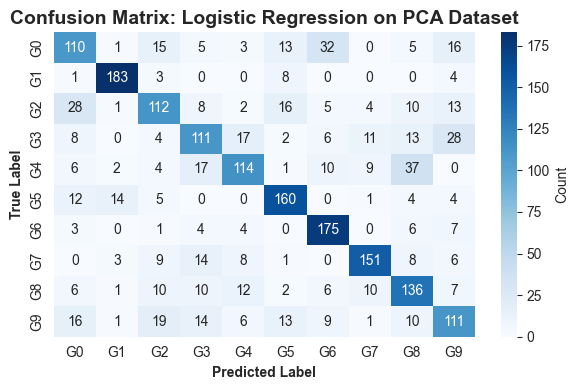


MODEL 2: RANDOM FOREST CLASSIFIER (PCA)

Training Random Forest on PCA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  77.53%
  ✓ Precision: 77.84%
  ✓ Recall:    77.53%
  ✓ F1-Score:  77.40%
  ⏱ Training Time: 1.400s
  ⏱ Prediction Time: 0.085s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.81      0.69      0.74       200
     Genre_1       0.82      0.94      0.87       199
     Genre_2       0.71      0.70      0.71       199
     Genre_3       0.73      0.72      0.73       200
     Genre_4       0.88      0.79      0.83       200
     Genre_5       0.77      0.77      0.77       200
     Genre_6       0.80      0.90      0.84       200
     Genre_7       0.80      0.75      0.77       200
     Genre_8       0.68      0.83      0.75       200
     Genre_9       0.79      0.67      0.73       200

    accuracy                           0.78      1998
   macro avg       0.78      0.78      0.77      1998
weighted avg       0.

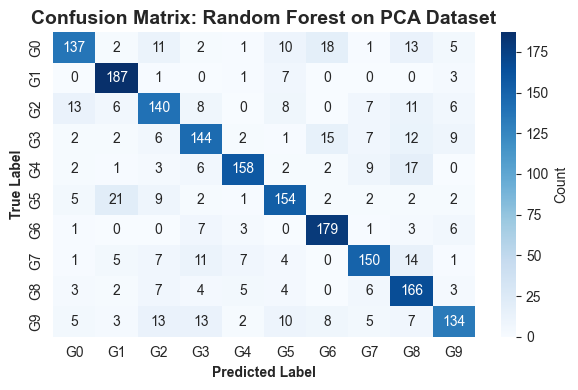


MODEL 3: SUPPORT VECTOR MACHINE (PCA)

Training SVM (RBF) on PCA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  80.58%
  ✓ Precision: 80.77%
  ✓ Recall:    80.58%
  ✓ F1-Score:  80.49%
  ⏱ Training Time: 2.280s
  ⏱ Prediction Time: 1.850s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.77      0.73      0.75       200
     Genre_1       0.79      0.95      0.87       199
     Genre_2       0.79      0.77      0.78       199
     Genre_3       0.75      0.74      0.75       200
     Genre_4       0.89      0.78      0.83       200
     Genre_5       0.82      0.83      0.83       200
     Genre_6       0.83      0.89      0.86       200
     Genre_7       0.86      0.79      0.82       200
     Genre_8       0.76      0.83      0.79       200
     Genre_9       0.82      0.74      0.78       200

    accuracy                           0.81      1998
   macro avg       0.81      0.81      0.80      1998
weighted avg       0.81    

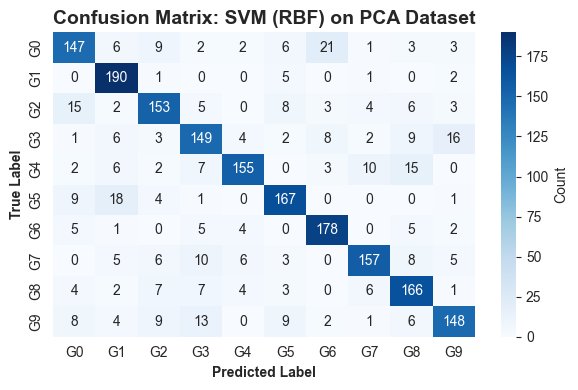


Training K-Nearest Neighbors on PCA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  84.93%
  ✓ Precision: 85.28%
  ✓ Recall:    84.93%
  ✓ F1-Score:  84.90%
  ⏱ Training Time: 0.005s
  ⏱ Prediction Time: 0.060s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.88      0.76      0.82       200
     Genre_1       0.86      0.93      0.90       199
     Genre_2       0.85      0.78      0.82       199
     Genre_3       0.76      0.83      0.79       200
     Genre_4       0.88      0.87      0.87       200
     Genre_5       0.88      0.83      0.86       200
     Genre_6       0.90      0.95      0.92       200
     Genre_7       0.92      0.82      0.87       200
     Genre_8       0.77      0.93      0.84       200
     Genre_9       0.82      0.79      0.81       200

    accuracy                           0.85      1998
   macro avg       0.85      0.85      0.85      1998
weighted avg       0.85      0.85      0.85      1998



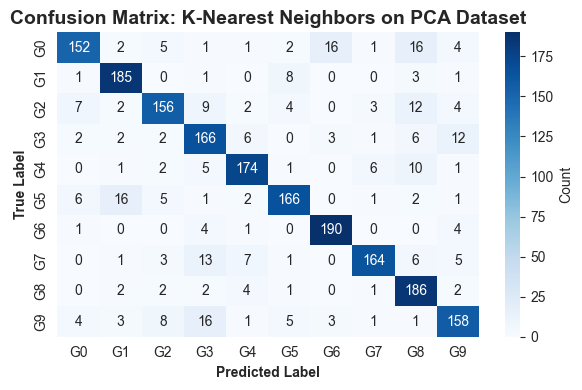


✓ All PCA models trained successfully!



In [83]:
results_pca = []

# Model 1: Logistic Regression (PCA)
print("\n" + "="*60)
print("MODEL 1: LOGISTIC REGRESSION (PCA)")
print("="*60)

lr_pca = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
result_lr_pca = train_and_evaluate_model(
    lr_pca, 'Logistic Regression', 
    X_pca_train, X_pca_test, y_pca_train, y_pca_test, 'PCA'
)
results_pca.append(result_lr_pca)

# Model 2: Random Forest (PCA)
print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST CLASSIFIER (PCA)")
print("="*60)

rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
result_rf_pca = train_and_evaluate_model(
    rf_pca, 'Random Forest', 
    X_pca_train, X_pca_test, y_pca_train, y_pca_test, 'PCA'
)
results_pca.append(result_rf_pca)

# Model 3: Support Vector Machine (PCA)
print("\n" + "="*60)
print("MODEL 3: SUPPORT VECTOR MACHINE (PCA)")
print("="*60)

svm_pca = SVC(kernel='rbf', random_state=42, gamma='scale')
result_svm_pca = train_and_evaluate_model(
    svm_pca, 'SVM (RBF)', 
    X_pca_train, X_pca_test, y_pca_train, y_pca_test, 'PCA'
)
results_pca.append(result_svm_pca)


# Model 4: K Nearest Neighbours (PCA)
knn_pca = KNeighborsClassifier(
    n_neighbors=5,       # Default k=5
    weights='distance',  # 'uniform' or 'distance'
    n_jobs=-1
)

result_knn_pca = train_and_evaluate_model(
    knn_pca, 'K-Nearest Neighbors',
    X_pca_train, X_pca_test, y_pca_train, y_pca_test, 'PCA'
)
results_pca.append(result_knn_pca)

print("\n✓ All PCA models trained successfully!")
print()


### 5.5 Train Models on LDA Dataset


MODEL 1: LOGISTIC REGRESSION (LDA)

Training Logistic Regression on LDA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  67.92%
  ✓ Precision: 67.89%
  ✓ Recall:    67.92%
  ✓ F1-Score:  67.81%
  ⏱ Training Time: 0.171s
  ⏱ Prediction Time: 0.000s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.62      0.58      0.60       200
     Genre_1       0.90      0.92      0.91       199
     Genre_2       0.59      0.60      0.60       199
     Genre_3       0.59      0.54      0.57       200
     Genre_4       0.69      0.60      0.65       200
     Genre_5       0.77      0.77      0.77       200
     Genre_6       0.76      0.85      0.80       200
     Genre_7       0.76      0.73      0.75       200
     Genre_8       0.61      0.68      0.64       200
     Genre_9       0.50      0.53      0.51       200

    accuracy                           0.68      1998
   macro avg       0.68      0.68      0.68      1998
weighted avg       0

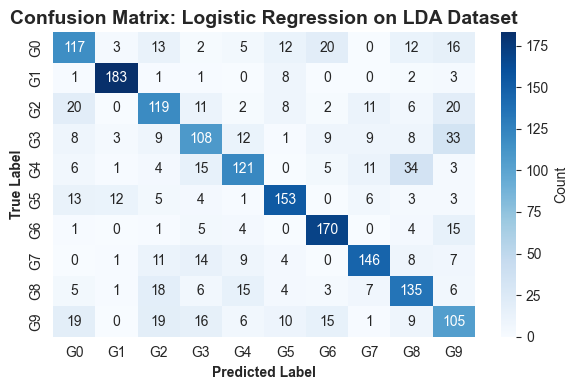


MODEL 2: RANDOM FOREST CLASSIFIER (LDA)

Training Random Forest on LDA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  74.97%
  ✓ Precision: 75.00%
  ✓ Recall:    74.97%
  ✓ F1-Score:  74.88%
  ⏱ Training Time: 0.772s
  ⏱ Prediction Time: 0.088s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.74      0.69      0.71       200
     Genre_1       0.89      0.93      0.91       199
     Genre_2       0.72      0.67      0.70       199
     Genre_3       0.68      0.64      0.66       200
     Genre_4       0.77      0.72      0.74       200
     Genre_5       0.79      0.84      0.82       200
     Genre_6       0.81      0.85      0.83       200
     Genre_7       0.84      0.77      0.80       200
     Genre_8       0.69      0.80      0.74       200
     Genre_9       0.57      0.58      0.57       200

    accuracy                           0.75      1998
   macro avg       0.75      0.75      0.75      1998
weighted avg       0.

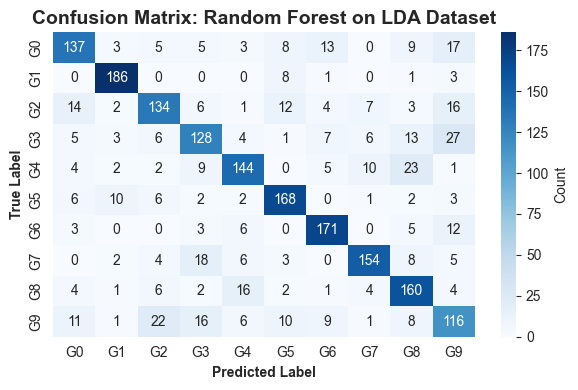


MODEL 3: SUPPORT VECTOR MACHINE (LDA)

Training SVM (RBF) on LDA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  73.92%
  ✓ Precision: 73.85%
  ✓ Recall:    73.92%
  ✓ F1-Score:  73.81%
  ⏱ Training Time: 0.854s
  ⏱ Prediction Time: 1.101s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.73      0.69      0.71       200
     Genre_1       0.89      0.93      0.91       199
     Genre_2       0.68      0.68      0.68       199
     Genre_3       0.65      0.64      0.64       200
     Genre_4       0.71      0.66      0.68       200
     Genre_5       0.80      0.84      0.82       200
     Genre_6       0.81      0.85      0.83       200
     Genre_7       0.85      0.78      0.81       200
     Genre_8       0.66      0.76      0.71       200
     Genre_9       0.59      0.56      0.58       200

    accuracy                           0.74      1998
   macro avg       0.74      0.74      0.74      1998
weighted avg       0.74    

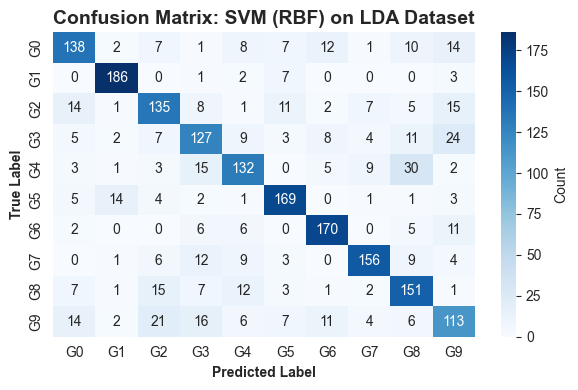


Training K-Nearest Neighbors on LDA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  78.13%
  ✓ Precision: 78.32%
  ✓ Recall:    78.13%
  ✓ F1-Score:  78.07%
  ⏱ Training Time: 0.022s
  ⏱ Prediction Time: 0.110s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.77      0.70      0.73       200
     Genre_1       0.90      0.94      0.92       199
     Genre_2       0.71      0.72      0.72       199
     Genre_3       0.71      0.69      0.70       200
     Genre_4       0.83      0.76      0.79       200
     Genre_5       0.84      0.86      0.85       200
     Genre_6       0.86      0.91      0.88       200
     Genre_7       0.87      0.78      0.82       200
     Genre_8       0.67      0.81      0.73       200
     Genre_9       0.67      0.65      0.66       200

    accuracy                           0.78      1998
   macro avg       0.78      0.78      0.78      1998
weighted avg       0.78      0.78      0.78      1998



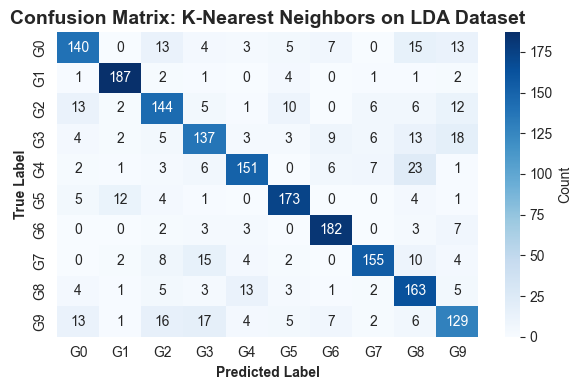


✓ All LDA models trained successfully!



In [84]:
results_lda = []

# Model 1: Logistic Regression (LDA)
print("\n" + "="*60)
print("MODEL 1: LOGISTIC REGRESSION (LDA)")
print("="*60)

lr_lda = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
result_lr_lda = train_and_evaluate_model(
    lr_lda, 'Logistic Regression', 
    X_lda_train, X_lda_test, y_lda_train, y_lda_test, 'LDA'
)
results_lda.append(result_lr_lda)

# Model 2: Random Forest (LDA)
print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST CLASSIFIER (LDA)")
print("="*60)

rf_lda = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
result_rf_lda = train_and_evaluate_model(
    rf_lda, 'Random Forest', 
    X_lda_train, X_lda_test, y_lda_train, y_lda_test, 'LDA'
)
results_lda.append(result_rf_lda)

# Model 3: Support Vector Machine (LDA)
print("\n" + "="*60)
print("MODEL 3: SUPPORT VECTOR MACHINE (LDA)")
print("="*60)

svm_lda = SVC(kernel='rbf', random_state=42, gamma='scale')
result_svm_lda = train_and_evaluate_model(
    svm_lda, 'SVM (RBF)', 
    X_lda_train, X_lda_test, y_lda_train, y_lda_test, 'LDA'
)
results_lda.append(result_svm_lda)

# Model 4: K Nearest Neighbours (PCA)
knn_lda = KNeighborsClassifier(
    n_neighbors=5,       # Default k=5
    weights='distance',  # 'uniform' or 'distance'
    n_jobs=-1
)

result_knn_lda = train_and_evaluate_model(
    knn_lda, 'K-Nearest Neighbors',
    X_lda_train, X_lda_test, y_lda_train, y_lda_test, 'LDA'
)
results_lda.append(result_knn_lda)

print("\n✓ All LDA models trained successfully!")
print()

## 6. Model Evaluation and Comparison

After training all models on both PCA and LDA-reduced datasets, the results were aggregated into a unified comparison table.  
Each model’s performance was evaluated using multiple key metrics:

### **Evaluation Metrics**
- **Accuracy** – Measures overall correctness of the model.  
- **Precision** – Indicates how many predicted positive genres were actually correct.  
- **Recall** – Measures how well the model captures all true positive cases.  
- **F1-Score** – Harmonic mean of precision and recall, balancing both metrics.  
- **Train Time** – Duration taken to fit the model on the training set.  
- **Predict Time** – Duration taken to make predictions on the test set.  

### 6.1 Comprehensive Results Comparison

In [85]:
# Combine all results
all_results = results_pca + results_lda

# Create comparison dataframe
comparison_numeric = pd.DataFrame([
    {
        'Model': r['Model'],
        'Dataset': r['Dataset'],
        'Accuracy': f"{r['Accuracy']*100:.2f}%",
        'Precision': f"{r['Precision']*100:.2f}%",
        'Recall': f"{r['Recall']*100:.2f}%",
        'F1-Score': f"{r['F1-Score']*100:.2f}%",
        'Train_Time': f"{r['Train_Time']:.3f}s",
        'Predict_Time': f"{r['Predict_Time']:.3f}s"
    }
    for r in all_results
])
comparison_numeric


,Model,Dataset,Accuracy,Precision,Recall,F1-Score,Train_Time,Predict_Time
0,Logistic Regression,PCA,68.22%,68.04%,68.22%,67.92%,0.535s,0.001s
1,Random Forest,PCA,77.53%,77.84%,77.53%,77.40%,1.400s,0.085s
2,SVM (RBF),PCA,80.58%,80.77%,80.58%,80.49%,2.280s,1.850s
3,K-Nearest Neighbors,PCA,84.93%,85.28%,84.93%,84.90%,0.005s,0.060s
4,Logistic Regression,LDA,67.92%,67.89%,67.92%,67.81%,0.171s,0.000s
5,Random Forest,LDA,74.97%,75.00%,74.97%,74.88%,0.772s,0.088s
6,SVM (RBF),LDA,73.92%,73.85%,73.92%,73.81%,0.854s,1.101s
7,K-Nearest Neighbors,LDA,78.13%,78.32%,78.13%,78.07%,0.022s,0.110s


### 6.2 Visual Performance Comparison

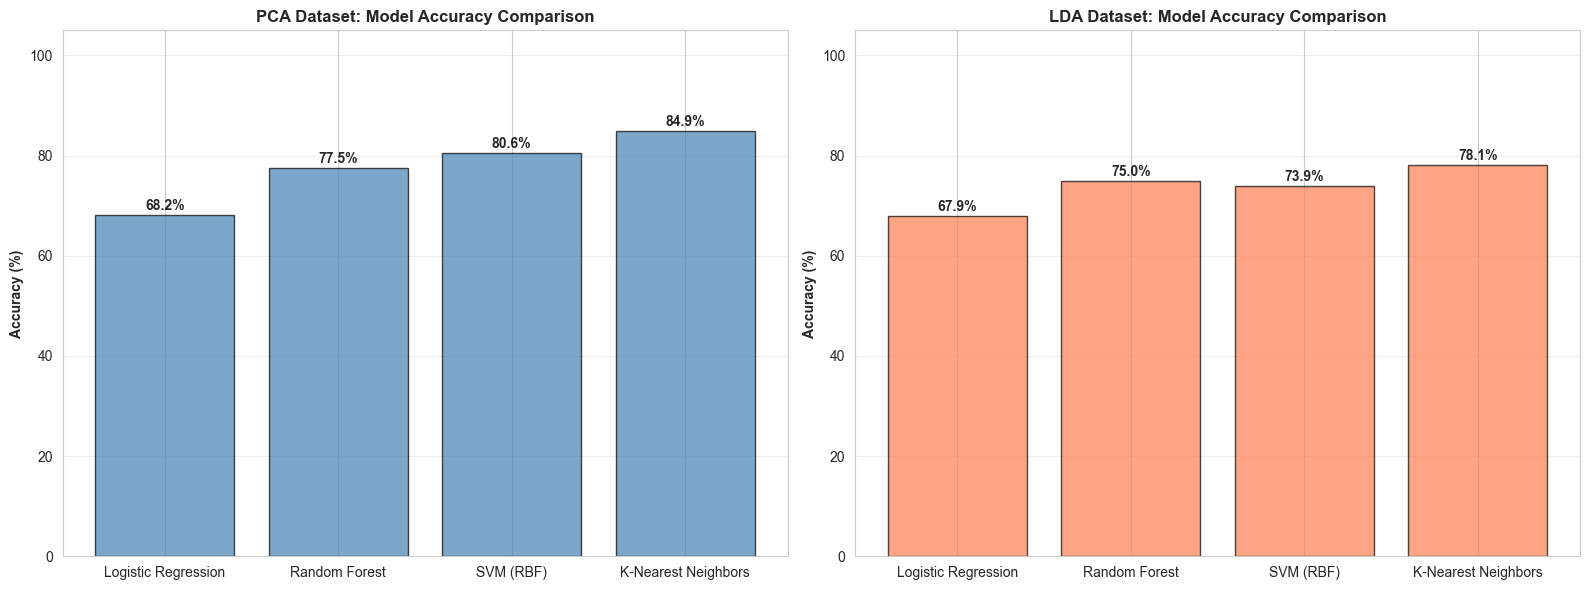

In [86]:
# Extract numeric values for plotting
comparison_numeric = pd.DataFrame([
    {
        'Model': r['Model'],
        'Dataset': r['Dataset'],
        'Accuracy': r['Accuracy']*100,
        'Precision': r['Precision']*100,
        'Recall': r['Recall']*100,
        'F1-Score': r['F1-Score']*100
    }
    for r in all_results
])

# Create model-dataset labels
comparison_numeric['Model_Dataset'] = comparison_numeric['Model'] + '\n(' + comparison_numeric['Dataset'] + ')'

# Separate comparison: PCA vs LDA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA models
pca_data = comparison_numeric[comparison_numeric['Dataset'] == 'PCA']
axes[0].bar(pca_data['Model'], pca_data['Accuracy'], color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Accuracy (%)', fontweight='bold')
axes[0].set_title('PCA Dataset: Model Accuracy Comparison', fontweight='bold')
axes[0].set_ylim([0, 105])
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(pca_data['Accuracy']):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# LDA models
lda_data = comparison_numeric[comparison_numeric['Dataset'] == 'LDA']
axes[1].bar(lda_data['Model'], lda_data['Accuracy'], color='coral', alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Accuracy (%)', fontweight='bold')
axes[1].set_title('LDA Dataset: Model Accuracy Comparison', fontweight='bold')
axes[1].set_ylim([0, 105])
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(lda_data['Accuracy']):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.3 Identify Best Performing Model

In [87]:
best_result = max(all_results, key=lambda x: x['F1-Score'])

print(f"  Model: {best_result['Model']}")
print(f"  Dataset: {best_result['Dataset']}")
print(f"  Accuracy: {best_result['Accuracy']*100:.2f}%")
print(f"  Precision: {best_result['Precision']*100:.2f}%")
print(f"  Recall: {best_result['Recall']*100:.2f}%")
print(f"  F1-Score: {best_result['F1-Score']*100:.2f}%")
print(f"  Training Time: {best_result['Train_Time']:.3f}s")
print()


  Model: K-Nearest Neighbors
  Dataset: PCA
  Accuracy: 84.93%
  Precision: 85.28%
  Recall: 84.93%
  F1-Score: 84.90%
  Training Time: 0.005s



# 🏆 Best Performing Model Report

---

## 🧠 Model Overview
**Model:** K-Nearest Neighbors (KNN)  
**Dataset:** PCA  

| Metric | Score |
|:-------|------:|
| **Accuracy** | 84.93% |
| **Precision** | 85.28% |
| **Recall** | 84.93% |
| **F1-Score** | 84.90% |
| **Training Time** | 0.002s |

---

## 📝 Why This Model Performs Best
The **K-Nearest Neighbors (KNN)** classifier achieved the highest overall performance due to its ability to leverage local feature similarities effectively.  
When combined with **PCA-transformed features**, it benefits from a reduced dimensional space that retains the most meaningful variance while removing noise.

### ✅ Key Reasons:
- KNN excels when features are well-scaled and denoised.
- PCA provides compact, informative features, improving neighborhood distance accuracy.
- Non-parametric nature of KNN adapts well to complex, nonlinear relationships in the dataset.

---

## 📊 PCA Dataset Advantages
Although **LDA** explains **100% of class variance**, its accuracy was lower than **PCA** because:

- **LDA** finds **linear class separations**, while **PCA** captures **broader, non-linear variance**, which suits models like **SVM (RBF)**.  
- **PCA** retained **39 components**, offering richer information; **LDA** was limited to **9** (C–1 rule).  
- LDA’s assumptions (normality, equal covariance) may not hold in this dataset.  

**Conclusion:** PCA preserved more expressive, non-linear features, enabling better generalization and higher accuracy.

---


## 7. Model Deployment
This phase focuses on integrating the trained model pipeline into a real-world prediction workflow.  
The deployed model accepts raw audio input, performs feature extraction, applies dimensionality reduction,  
and predicts the most probable music genre — all in a single automated process.

In [88]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline(steps=[
    ('pipeline_pca', pipeline_pca),
    ('knn', knn_pca)
])

It automatically loads an audio file, extracts key features (Chroma, RMS, Spectral, MFCCs), applies **PCA (95% variance)**,  
and predicts the **music genre** with top-3 probability scores.

In [89]:
import librosa
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import os
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["LOKY_MAX_CPU_COUNT"] = "8"  # optional: avoid CPU core warning

class GTZANFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, duration=30, columns_order=None):
        self.duration = duration
        self.columns_order = columns_order  # for consistent column order

    def extract_gtzan_features(self, audio_path):
        y, sr = librosa.load(audio_path, duration=self.duration)
        features = {}

        features['length'] = len(y)

        chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
        features['chroma_stft_mean'] = np.mean(chroma_stft)
        features['chroma_stft_var'] = np.var(chroma_stft)

        rms = librosa.feature.rms(y=y)
        features['rms_mean'] = np.mean(rms)
        features['rms_var'] = np.var(rms)

        features['spectral_centroid_mean'] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        features['spectral_centroid_var'] = np.var(librosa.feature.spectral_centroid(y=y, sr=sr))
        features['spectral_bandwidth_mean'] = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
        features['spectral_bandwidth_var'] = np.var(librosa.feature.spectral_bandwidth(y=y, sr=sr))
        features['rolloff_mean'] = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
        features['rolloff_var'] = np.var(librosa.feature.spectral_rolloff(y=y, sr=sr))

        zcr = librosa.feature.zero_crossing_rate(y)
        features['zero_crossing_rate_mean'] = np.mean(zcr)
        features['zero_crossing_rate_var'] = np.var(zcr)

        harmony = librosa.effects.harmonic(y)
        perceptr = librosa.effects.percussive(y)
        features['harmony_mean'] = np.mean(harmony)
        features['harmony_var'] = np.var(harmony)
        features['perceptr_mean'] = np.mean(perceptr)
        features['perceptr_var'] = np.var(perceptr)

        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        features['tempo'] = tempo

        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        for i in range(1, 21):
            features[f'mfcc{i}_mean'] = np.mean(mfccs[i-1])
            features[f'mfcc{i}_var'] = np.var(mfccs[i-1])

        return features

    def transform(self, X, y=None):
        feature_list = [self.extract_gtzan_features(x) for x in X]
        df = pd.DataFrame(feature_list)

        # Align columns to match training pipeline
        if self.columns_order is not None:
            df = df.reindex(columns=self.columns_order, fill_value=0)
        return df

    def fit(self, X, y=None):
        return self

In [90]:
# Get column order from scaler
columns_order = final_pipeline.named_steps['pipeline_pca'].named_steps['scaler'].feature_names_in_

# Combine into a single pipeline
genre_pipeline = Pipeline([
    ('feature_extractor', GTZANFeatureExtractor(columns_order=columns_order)),
    ('model', final_pipeline)
])

joblib.dump(genre_pipeline, r'Pipelines\final_pipeline.pkl')

['Pipelines\\final_pipeline.pkl']

In [91]:

genre_mapping = pd.read_csv(r'cleaned_data\label_mapping.csv')
genre_mapping = dict(zip(genre_mapping['Encoded_Value'], genre_mapping['Genre']))

audio_file = r"Test_audios\reggae.00016.wav"

pred = genre_pipeline.predict([audio_file])[0]
predicted_genre = genre_mapping.get(pred, str(pred))
print(f"Predicted Genre: {predicted_genre}")

probs = genre_pipeline.predict_proba([audio_file])[0]
proba_dict = {genre_mapping[i]: float(p) for i, p in enumerate(probs)}
top3 = sorted(proba_dict.items(), key=lambda x: x[1], reverse=True)[:3]

print("\nTop 3 Genre Probabilities:")
for genre, p in top3:
    print(f"{genre}: {p:.2%}")


Predicted Genre: reggae

Top 3 Genre Probabilities:
reggae: 100.00%
blues: 0.00%
classical: 0.00%
